In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import platform
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import lightgbm as lgb
import xgboost as xgb

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 120

SEED = 42
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [2]:
# 데이터 로드
df = pd.read_csv('data/E Commerce Dataset.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [3]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [4]:
df.info()
print()
print(f"원본 데이터: {df.shape[0]:,}행 × {df.shape[1]}컬럼")
print(f"이탈 비율: {df['Churn'].mean()*100:.1f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
X_cd_df = df.drop('Churn', axis=1)
y_cd_df = df['Churn']
display(X_cd_df)
display(y_cd_df)

,CustomerID,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,151
5626,55627,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,225
5627,55628,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186
5628,55629,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,179


0       1
1       1
2       1
3       1
4       1
       ..
5625    0
5626    0
5627    0
5628    0
5629    0
Name: Churn, Length: 5630, dtype: int64

## 1. 전처리 함수 정의

전처리 파이프라인을 단계별 함수로 정의합니다.

| 함수 | 역할 | 적용 시점 |
|---|---|---|
| `load_data` | CSV 로드 | - |
| `normalize_categories` | 범주값 통합 | 로드 직후 |
| `fill_missing` | 결측치 처리 | - |
| `handle_outliers` | log1p 변환 | - |
| `encode_features` | One-Hot + Label Encoding | - |
| `split_data` | Train/Val/Test 분리 | - |
| `add_bin_features` | 왜도 큰 변수 → 구간 서열 정수 | **스케일링 전** |
| `scale_features` | StandardScaler | - |
| `add_group_features` | 그룹 합성 점수 컬럼 추가 | **스케일링 후** |
| `preprocess_pipeline` | 전체 파이프라인 실행 | - |

In [6]:
# 전처리 함수 정의

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    print(f"[load_data]  {df.shape[0]:,}행 × {df.shape[1]}컬럼  |  이탈율 {df['Churn'].mean()*100:.1f}%")
    return df


def normalize_categories(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})
    df["PreferedOrderCat"]     = df["PreferedOrderCat"].replace({"Mobile Phone": "Mobile"})
    df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace(
        {"Cash on Delivery": "COD", "CC": "Credit Card"}
    )
    print("[normalize_categories]  범주값 통합 완료")
    return df


def fill_missing(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    missing_cols = ["DaySinceLastOrder","OrderAmountHikeFromlastYear","Tenure",
                    "OrderCount","CouponUsed","HourSpendOnApp","WarehouseToHome"]
    for col in missing_cols:
        df[col] = df[col].fillna(df[col].mean() if col == "HourSpendOnApp" else df[col].median())
    print(f"[fill_missing]  결측치 처리 완료  |  잔여 NaN: {df.isnull().sum().sum()}개")
    return df


def handle_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["OrderCount_log"] = np.log1p(df["OrderCount"])
    df["CouponUsed_log"] = np.log1p(df["CouponUsed"])
    df = df.drop(columns=["OrderCount","CouponUsed","CustomerID"], errors="ignore")
    print("[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)")
    return df


def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["CityTier"] = df["CityTier"].astype(str)
    df = pd.get_dummies(df, columns=["CityTier"], prefix="CityTier")
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)
    df = df.drop(columns=["CityTier_1"], errors="ignore")   # 다중공선성 제거

    cat_cols = ["PreferredLoginDevice","PreferredPaymentMode",
                "Gender","PreferedOrderCat","MaritalStatus"]
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))

    print(f"[encode_features]  인코딩 완료  |  최종 컬럼 수: {df.shape[1]}개")
    return df


def split_data(df: pd.DataFrame, target: str = "Churn", seed: int = SEED):
    X = df.drop(columns=[target])
    y = df[target]
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=seed)
    X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=seed)
    print(f"[split_data]  Train:{len(X_train):,} | Val:{len(X_val):,} | Test:{len(X_test):,}")
    return X_train, X_val, X_test, y_train, y_val, y_test


def scale_features(X_train, X_val, X_test):
    X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()
    num_cols = ["Tenure","WarehouseToHome","HourSpendOnApp","NumberOfDeviceRegistered",
                "SatisfactionScore","NumberOfAddress","OrderAmountHikeFromlastYear",
                "DaySinceLastOrder","CashbackAmount","OrderCount_log","CouponUsed_log"]
    scale_cols = [c for c in num_cols if c in X_train.columns]
    scaler = StandardScaler()
    X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
    X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
    X_test[scale_cols]  = scaler.transform(X_test[scale_cols])
    print(f"[scale_features]  StandardScaler 적용 완료  |  {len(scale_cols)}개 컬럼")
    return X_train, X_val, X_test, scaler


print("✅ 기본 전처리 함수 정의 완료")

✅ 기본 전처리 함수 정의 완료


## 2. 추가 피처 함수 정의

### 2-1. 왜도 구간 피처 함수
> ⚠️ 반드시 **스케일링 전** 원본 스케일 데이터에 적용해야 합니다.

In [7]:
# ── 구간 설정 (Preprocessing.ipynb 분석 결과 동일) ────────────────────────
BIN_CONFIGS = {
    "CouponUsed_log": {
        "bins"  : [0, 1, 3, 6, 10, 17],
        "labels": ["0_미사용", "1_낮음", "2_중간", "3_높음", "4_단골"],
        "col_name": "CouponUsed_bin"
    },
    "OrderCount_log": {
        "bins"  : [1, 2, 4, 7, 10, 17],
        "labels": ["0_초기", "1_낮음", "2_중간", "3_높음", "4_단골"],
        "col_name": "OrderCount_bin"
    },
    "WarehouseToHome": {
        "bins"  : [0, 10, 20, 30, 50, 130],
        "labels": ["0_가깝", "1_10_20km", "2_20_30km", "3_30_50km", "4_50km이상"],
        "col_name": "WarehouseToHome_bin"
    },
    "Tenure": {
        "bins"  : [0, 3, 6, 12, 24, 62],
        "labels": ["0_입문", "1_초기", "2_성장", "3_안정기", "4_장기"],
        "col_name": "Tenure_bin"
    },
}


def add_bin_features(X: pd.DataFrame) -> pd.DataFrame:

    X = X.copy()
    for src_col, cfg in BIN_CONFIGS.items():
        if src_col not in X.columns:
            continue
        binned = pd.cut(
            X[src_col],
            bins=cfg["bins"],
            labels=cfg["labels"],
            include_lowest=True
        )
        # 범주형 → 서열 정수 (0, 1, 2, 3, 4)
        X[cfg["col_name"]] = binned.cat.codes          # NaN이면 -1, 정상이면 0~4
    added = [cfg["col_name"] for cfg in BIN_CONFIGS.values() if cfg["col_name"] in X.columns]
    print(f"[add_bin_features]  구간 피처 추가 완료: {added}")
    return X


print("✅ add_bin_features 정의 완료")

✅ add_bin_features 정의 완료


### 2-2. 변수 그룹핑 합성 점수 함수

In [8]:
# ── 그룹 정의 (Preprocessing.ipynb Cell 52 동일) ──────────────────────────
# CityTier_1 제거 이후 기준: "가계 경제력" 그룹에서 CityTier_1 제외
VAR_GROUPS = {
    "GRP_LifestageRisk": ["MaritalStatus", "Complain"],
    "GRP_PromoGap"  : ["CouponUsed_log", "SatisfactionScore", "Complain"],
    "GRP_TenureFatigue"    : ["Tenure", "Complain"],
    "GRP_LogDistress"      : ["WarehouseToHome", "Complain"],
    "GRP_LoyLockIn"    : ["Tenure", "CashbackAmount","SatisfactionScore"],
    "GRP_LivStability"    : ["CityTier_2", "CityTier_3", "NumberOfAddress"],
    "GRP_PfDep"  : ["DaySinceLastOrder", "OrderCount_log", "CouponUsed_log"],
}


def add_group_features(X_train, X_val, X_test):

    results = []
    for X in [X_train, X_val, X_test]:
        X = X.copy()
        for grp_name, cols in VAR_GROUPS.items():
            exist_cols = [c for c in cols if c in X.columns]
            if len(exist_cols) >= 2:                     # 2개 이상 있을 때만 합성
                X[grp_name] = X[exist_cols].mean(axis=1)
        results.append(X)

    added = [g for g, cols in VAR_GROUPS.items()
             if sum(1 for c in cols if c in results[0].columns) >= 2]
    print(f"[add_group_features]  그룹 피처 추가 완료 ({len(added)}개): {added}")
    return results[0], results[1], results[2]


print("✅ add_group_features 정의 완료")

✅ add_group_features 정의 완료


In [9]:
## 3. 전처리 파이프라인 실행

In [10]:
def preprocess_pipeline(path: str):
    """
    전처리 파이프라인 실행 순서:
    load → normalize → fill_missing → outliers → encode
    → split → [add_bin_features] → scale → return
    ※ add_group_features는 파이프라인 후 별도 호출 (분석 시각화 연계)
    """
    print("=" * 58)
    print("  전처리 파이프라인 시작")
    print("=" * 58)
    df = load_data(path)
    df = normalize_categories(df)
    df = fill_missing(df)
    df = handle_outliers(df)
    df = encode_features(df)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

    # ── bin 피처: 스케일링 전 원본 스케일에서 적용 ─────────────────────
    X_train = add_bin_features(X_train)
    X_val   = add_bin_features(X_val)
    X_test  = add_bin_features(X_test)

    # ── 스케일링 (bin 컬럼은 수치형 목록에 없으므로 자동 제외) ──────────
    X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test)

    scale_pw = round((y_train == 0).sum() / (y_train == 1).sum(), 4)
    print(f"[class_weight]  scale_pos_weight = {scale_pw}")
    print("=" * 58)
    print("  ✅ 파이프라인 완료 (그룹 피처는 아래 셀에서 추가)")
    print("=" * 58)
    return X_train, X_val, X_test, y_train, y_val, y_test, scale_pw, scaler


DATA_PATH = "data/E Commerce Dataset.csv"
X_train, X_val, X_test, y_train, y_val, y_test, scale_pw, scaler = preprocess_pipeline(DATA_PATH)

  전처리 파이프라인 시작
[load_data]  5,630행 × 20컬럼  |  이탈율 16.8%
[normalize_categories]  범주값 통합 완료
[fill_missing]  결측치 처리 완료  |  잔여 NaN: 0개
[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)
[encode_features]  인코딩 완료  |  최종 컬럼 수: 20개
[split_data]  Train:3,378 | Val:1,126 | Test:1,126
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[scale_features]  StandardScaler 적용 완료  |  11개 컬럼
[class_weight]  scale_pos_weight = 4.9367
  ✅ 파이프라인 완료 (그룹 피처는 아래 셀에서 추가)


## 3. 데이터 분리

In [11]:
df_processed = load_data(DATA_PATH)
df_processed = normalize_categories(df_processed)
df_processed = fill_missing(df_processed)
df_processed = handle_outliers(df_processed)
df_processed = encode_features(df_processed)

X = df_processed.drop(columns=["Churn"])
y = df_processed["Churn"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

# bin 피처 (스케일링 전)
X_train = add_bin_features(X_train)
X_val   = add_bin_features(X_val)
X_test  = add_bin_features(X_test)

# 스케일링
X_train, X_val, X_test, scaler = scale_features(X_train, X_val, X_test)

# 그룹 피처 (스케일링 후)
X_train, X_val, X_test = add_group_features(X_train, X_val, X_test)


[load_data]  5,630행 × 20컬럼  |  이탈율 16.8%
[normalize_categories]  범주값 통합 완료
[fill_missing]  결측치 처리 완료  |  잔여 NaN: 0개
[handle_outliers]  log1p 변환 완료 (OrderCount_log, CouponUsed_log)
[encode_features]  인코딩 완료  |  최종 컬럼 수: 20개
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[add_bin_features]  구간 피처 추가 완료: ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
[scale_features]  StandardScaler 적용 완료  |  11개 컬럼
[add_group_features]  그룹 피처 추가 완료 (7개): ['GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']


## 4. 왜도 변수 — 구간별 이탈률 분석 시각화

> 구간(bin)마다 이탈률이 어떻게 달라지는지 확인합니다.  
> 이 시각화는 **스케일링 전 원본 스케일** 데이터를 사용합니다.

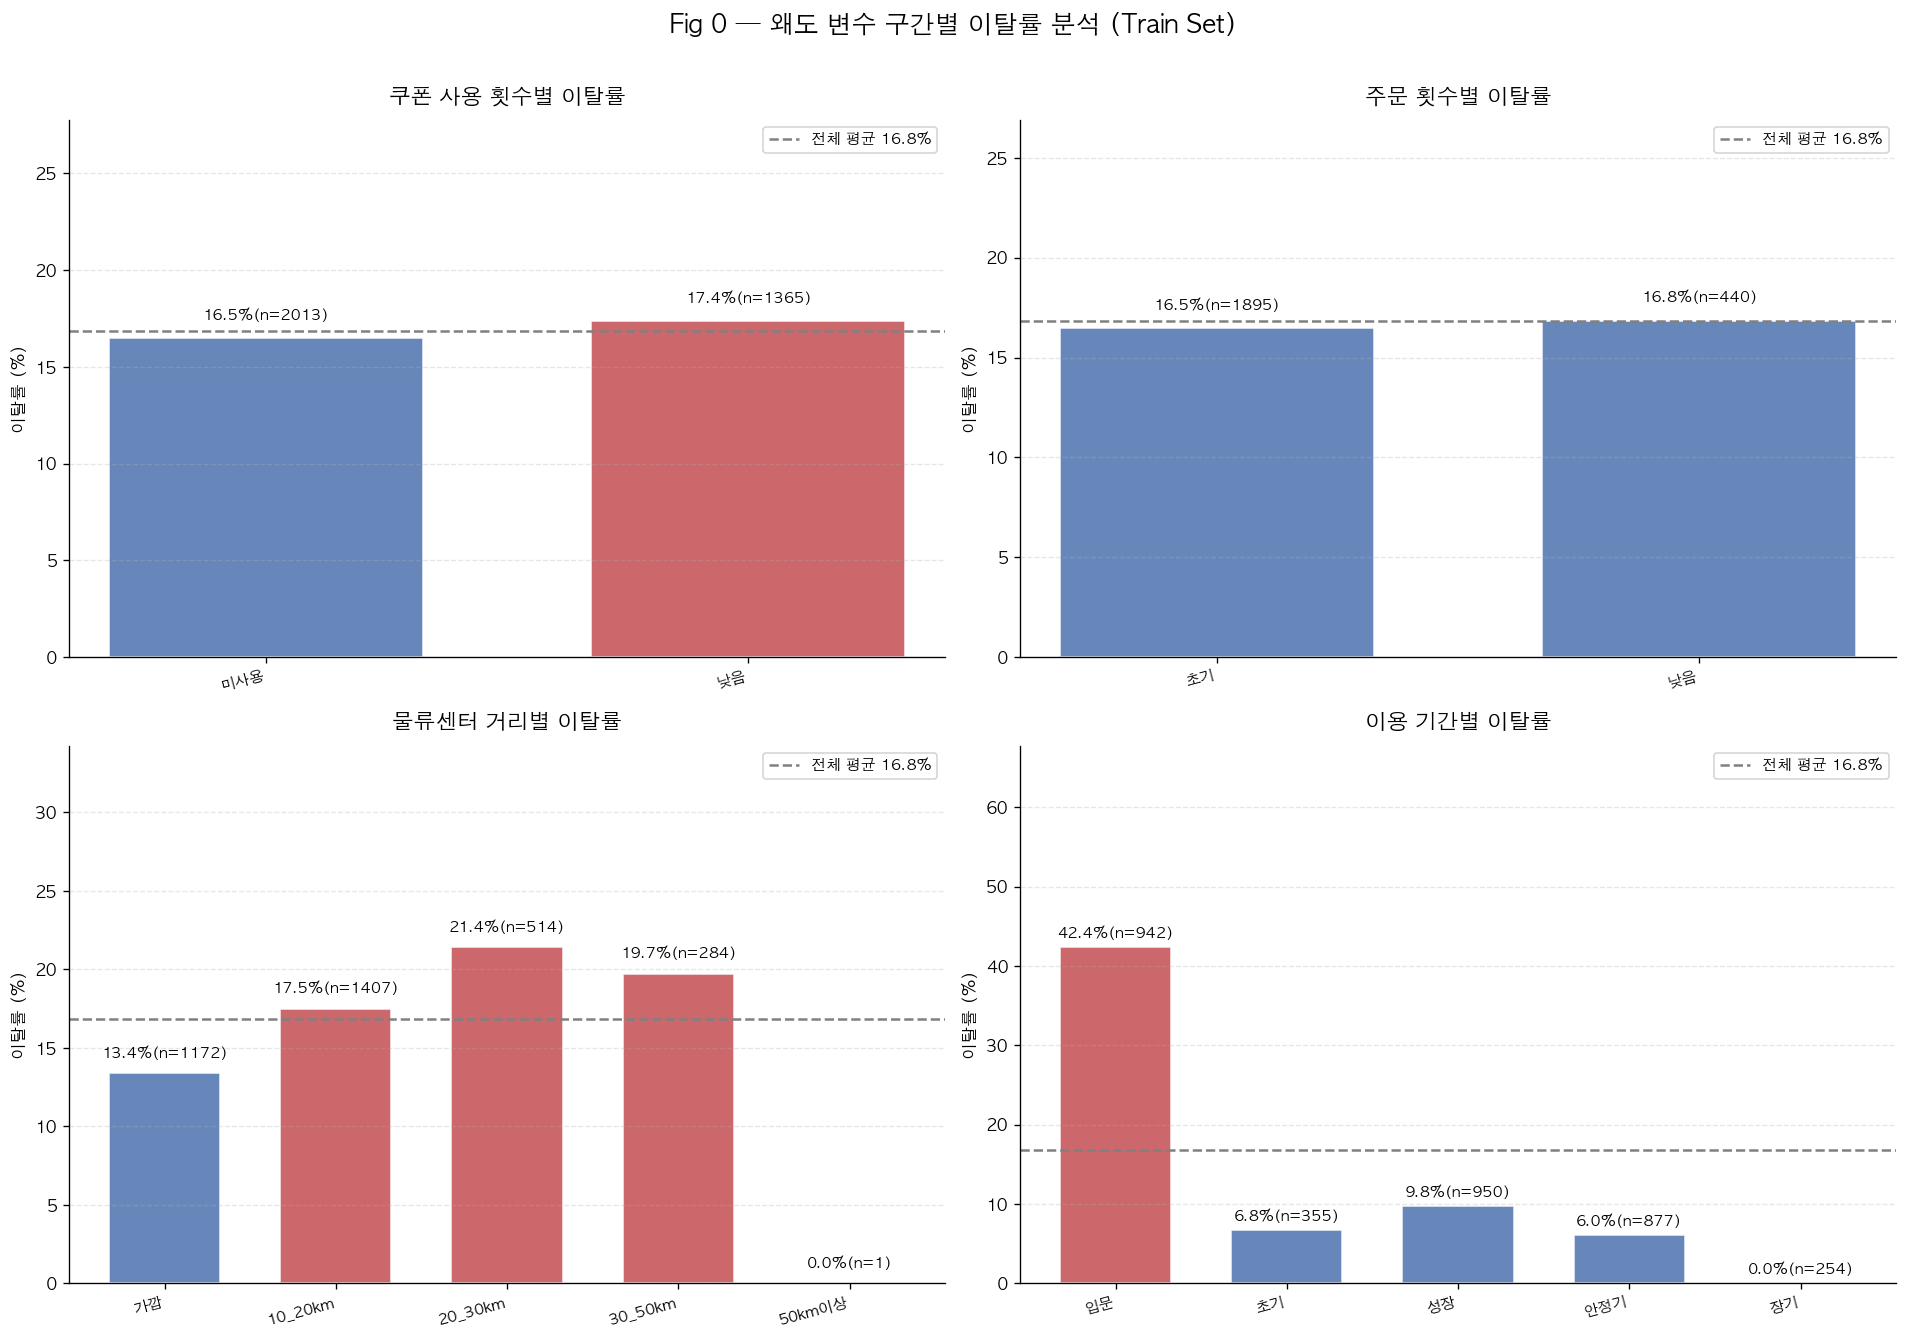

In [12]:
# ═══════════════════════════════════════════════════════════════════════
# 【Fig 0】 왜도 변수 구간별 이탈률 (Churn Rate by Bin)
# ═══════════════════════════════════════════════════════════════════════

# bin 컬럼명 → 원본 bin config 라벨 매핑
BIN_LABELS = {cfg["col_name"]: cfg["labels"] for cfg in BIN_CONFIGS.values()}
BIN_TITLES = {
    "CouponUsed_bin"    : "쿠폰 사용 횟수별 이탈률",
    "OrderCount_bin"    : "주문 횟수별 이탈률",
    "WarehouseToHome_bin": "물류센터 거리별 이탈률",
    "Tenure_bin"        : "이용 기간별 이탈률",
}

overall_churn = y_train.mean()

# 분석용 DataFrame (bin 코드 + Churn)
analysis = X_train[[c for c in X_train.columns if c.endswith("_bin")]].copy()
analysis["Churn"] = y_train.values

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (bin_col, title) in zip(axes, BIN_TITLES.items()):
    if bin_col not in analysis.columns:
        ax.set_visible(False)
        continue

    labels = BIN_LABELS[bin_col]
    # code → 라벨 표시용 문자 (숫자 접두사 제거)
    display_labels = [lbl.split("_", 1)[1] if "_" in lbl else lbl for lbl in labels]

    stats = (analysis
             .groupby(bin_col)["Churn"]
             .agg(["mean","count"])
             .reset_index())
    stats = stats[stats[bin_col] >= 0]   # -1(NaN 코드) 제외

    bar_colors = ["#C44E52" if v > overall_churn else "#4C72B0"
                  for v in stats["mean"]]

    bars = ax.bar(range(len(stats)), stats["mean"] * 100,
                  color=bar_colors, alpha=0.85, edgecolor="white", width=0.65)

    # 전체 평균선
    ax.axhline(overall_churn * 100, color="gray", lw=1.5, ls="--",
               label=f"전체 평균 {overall_churn*100:.1f}%")

    # 값 + 샘플수 레이블
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f"{row['mean']*100:.1f}%(n={int(row['count'])})",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

    tick_pos = list(range(len(stats)))
    ax.set_xticks(tick_pos)
    actual_labels = [display_labels[code] for code in stats[bin_col]]
    ax.set_xticklabels(actual_labels, fontsize=9, rotation=15, ha="right")
    ax.set_ylim(0, max(stats["mean"]) * 160)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("이탈률 (%)", fontsize=10)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Fig 0 — 왜도 변수 구간별 이탈률 분석 (Train Set)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. 그룹 합성 점수 피처 추가

In [13]:
# ── 스케일링 후 그룹 합성 점수 추가 ────────────────────────────────────
X_train, X_val, X_test = add_group_features(X_train, X_val, X_test)

print(f"\n📋 최종 피처 구성  ({X_train.shape[1]}개)")
print()

# 피처 카테고리별 출력
base_cols  = [c for c in X_train.columns if not c.startswith("grp_") and not c.endswith("_bin")]
bin_cols   = [c for c in X_train.columns if c.endswith("_bin")]
grp_cols   = [c for c in X_train.columns if c.startswith("grp_")]

print(f"  📌 기본 피처   ({len(base_cols)}개): {base_cols}")
print(f"  📌 구간 피처   ({len(bin_cols)}개): {bin_cols}")
print(f"  📌 그룹 피처   ({len(grp_cols)}개): {grp_cols}")
print(f"\n  ▶ 합계: {len(base_cols) + len(bin_cols) + len(grp_cols)}개")

[add_group_features]  그룹 피처 추가 완료 (7개): ['GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']

📋 최종 피처 구성  (30개)

  📌 기본 피처   (26개): ['Tenure', 'PreferredLoginDevice', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount', 'OrderCount_log', 'CouponUsed_log', 'CityTier_2', 'CityTier_3', 'GRP_LifestageRisk', 'GRP_PromoGap', 'GRP_TenureFatigue', 'GRP_LogDistress', 'GRP_LoyLockIn', 'GRP_LivStability', 'GRP_PfDep']
  📌 구간 피처   (4개): ['CouponUsed_bin', 'OrderCount_bin', 'WarehouseToHome_bin', 'Tenure_bin']
  📌 그룹 피처   (0개): []

  ▶ 합계: 30개


## 6. LightGBM 학습

In [14]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, num_leaves=31, max_depth=6,
    learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=20,
    scale_pos_weight=scale_pw, random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
print(f"✅ LightGBM 완료  |  Best iteration: {lgb_model.best_iteration_}")

✅ LightGBM 완료  |  Best iteration: 442


## 7. XGBoost 학습

In [15]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_weight=3, scale_pos_weight=scale_pw,
    eval_metric="auc", tree_method="hist", random_state=SEED,
    callbacks=[xgb.callback.EarlyStopping(rounds=50, metric_name="auc", save_best=True)]
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"✅ XGBoost 완료  |  Best iteration: {xgb_model.best_iteration}")

✅ XGBoost 완료  |  Best iteration: 497


## 8. 성능 평가

In [16]:
def find_best_threshold(model, X_val, y_val):
    prob = model.predict_proba(X_val)[:, 1]
    best_th, best_f1 = 0.5, 0.0
    for th in np.arange(0.30, 0.80, 0.01):
        f1 = f1_score(y_val, (prob >= th).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_th = f1, th
    return round(best_th, 2)

def evaluate(model, X, y, label, threshold=0.5):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    return {"모델": label, "Threshold": threshold,
            "Accuracy" : round(accuracy_score(y, pred), 4),
            "Precision": round(precision_score(y, pred, zero_division=0), 4),
            "Recall"   : round(recall_score(y, pred, zero_division=0), 4),
            "F1"       : round(f1_score(y, pred, zero_division=0), 4),
            "AUC"      : round(roc_auc_score(y, prob), 4)}

lgb_th = find_best_threshold(lgb_model, X_val, y_val)
xgb_th = find_best_threshold(xgb_model, X_val, y_val)
print(f"LightGBM 최적 임계값: {lgb_th}  |  XGBoost 최적 임계값: {xgb_th}")

LightGBM 최적 임계값: 0.39  |  XGBoost 최적 임계값: 0.35


In [17]:
results = [
    evaluate(lgb_model, X_val,  y_val,  "LightGBM  Val",  lgb_th),
    evaluate(lgb_model, X_test, y_test, "LightGBM  Test", lgb_th),
    evaluate(xgb_model, X_val,  y_val,  "XGBoost   Val",  xgb_th),
    evaluate(xgb_model, X_test, y_test, "XGBoost   Test", xgb_th),
]
result_df = pd.DataFrame(results).set_index("모델")
display(result_df.style
    .format({"Threshold":"{:.2f}","Accuracy":"{:.4f}","Precision":"{:.4f}",
             "Recall":"{:.4f}","F1":"{:.4f}","AUC":"{:.4f}"})
    .highlight_max(subset=["Accuracy","Precision","Recall","F1","AUC"], color="#c8f0c8")
    .set_caption("📊 모델 성능 비교 (초록=최고값)"))

,Threshold,Accuracy,Precision,Recall,F1,AUC
모델,,,,,,
LightGBM Val,0.39,0.9316,0.7897,0.8105,0.8000,0.9475
LightGBM Test,0.39,0.9458,0.7909,0.9206,0.8509,0.9735
XGBoost Val,0.35,0.9272,0.7523,0.8474,0.7970,0.9460
XGBoost Test,0.35,0.9343,0.7386,0.9418,0.8279,0.9713


## 9. 시각화

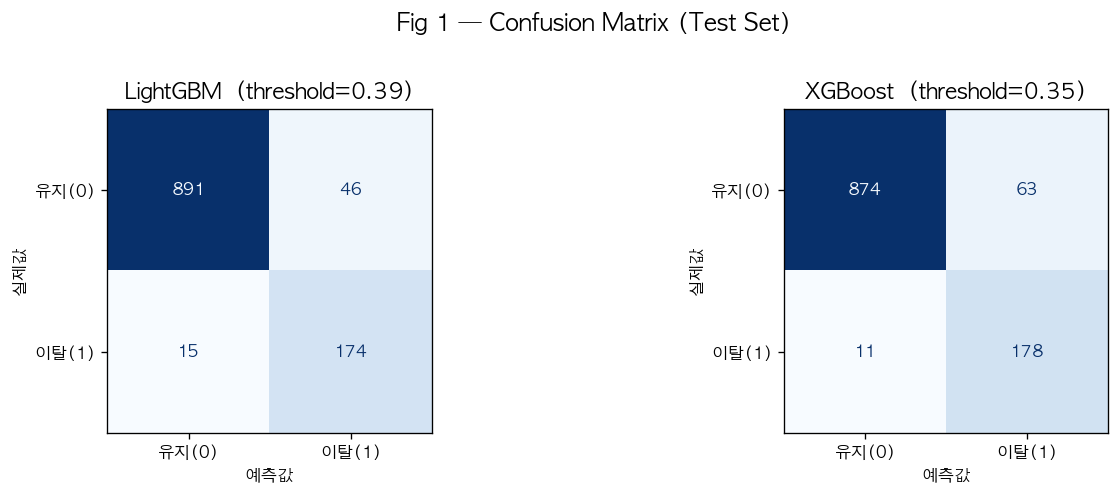

In [18]:
# ════════════════════════════════════════════════════════
# 【Fig 1】 Confusion Matrix (Test Set)
# ════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, name, th) in zip(axes, [
    (lgb_model, "LightGBM", lgb_th), (xgb_model, "XGBoost", xgb_th)
]):
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= th).astype(int)
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                                   display_labels=["유지(0)","이탈(1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}  (threshold={th})", fontsize=13, fontweight="bold")
    ax.set_xlabel("예측값"); ax.set_ylabel("실제값")
plt.suptitle("Fig 1 — Confusion Matrix (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

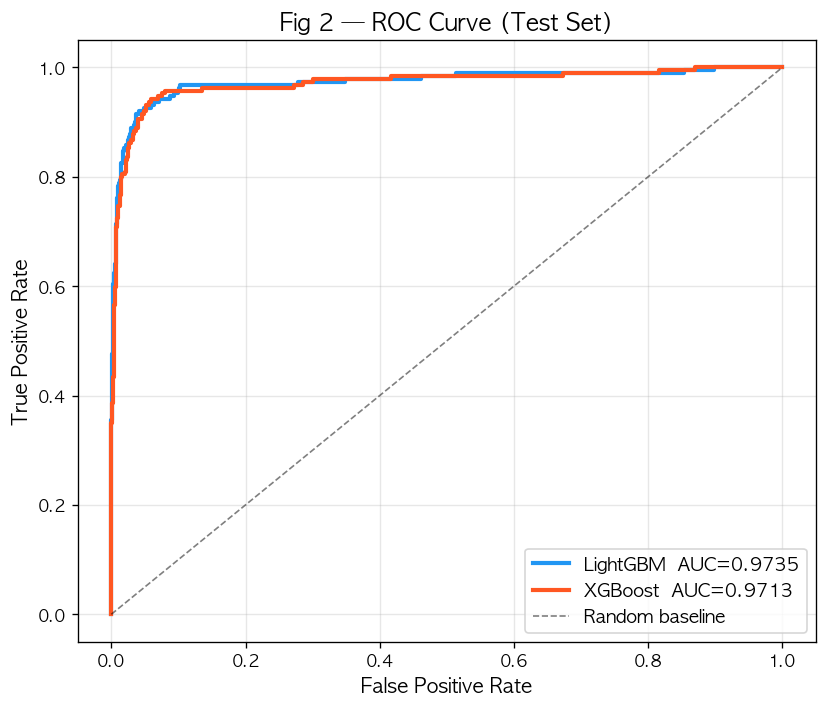

In [19]:
# ════════════════════════════════════════════════════════
# 【Fig 2】 ROC Curve (Test Set)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 6))
colors = {"LightGBM": "#2196F3", "XGBoost": "#FF5722"}
for model, name in [(lgb_model,"LightGBM"),(xgb_model,"XGBoost")]:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2.5, color=colors[name],
            label=f"{name}  AUC={roc_auc_score(y_test, prob):.4f}")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Random baseline")
ax.set_xlabel("False Positive Rate",fontsize=12); ax.set_ylabel("True Positive Rate",fontsize=12)
ax.set_title("Fig 2 — ROC Curve (Test Set)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

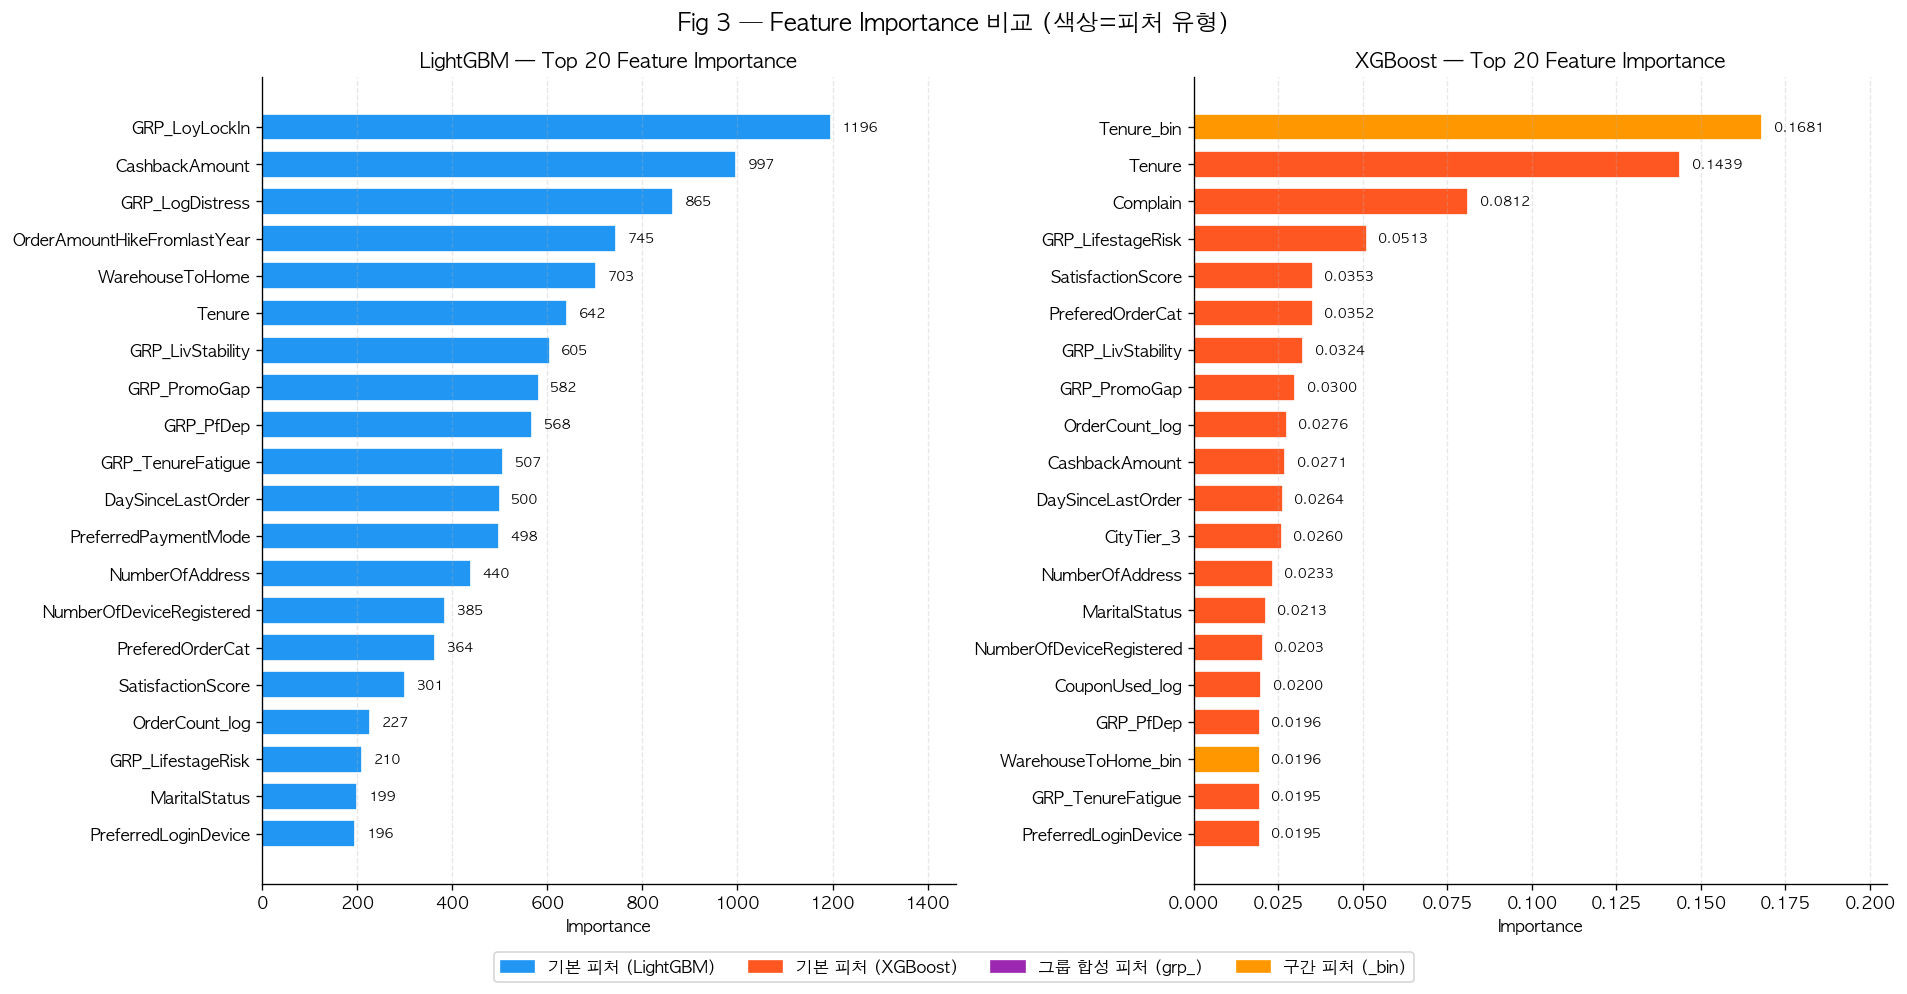

In [20]:
# ════════════════════════════════════════════════════════
# 【Fig 3】 Feature Importance Top-20 비교
# (그룹·구간 피처가 상위에 오르는지 확인)
# ════════════════════════════════════════════════════════
TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

fi_data = {
    "LightGBM": pd.Series(lgb_model.feature_importances_, index=X_train.columns).nlargest(TOP_N),
    "XGBoost" : pd.Series(xgb_model.feature_importances_, index=X_train.columns).nlargest(TOP_N),
}
palette = {"LightGBM": "#2196F3", "XGBoost": "#FF5722"}

# 피처 유형별 색상 구분
def bar_color(col_name, base_color):
    if col_name.startswith("grp_"):   return "#9C27B0"   # 보라: 그룹 피처
    if col_name.endswith("_bin"):     return "#FF9800"   # 주황: 구간 피처
    return base_color                                     # 기본: 모델 색상

for ax, (name, fi) in zip(axes, fi_data.items()):
    fi_sorted = fi.sort_values(ascending=True)
    colors_bar = [bar_color(col, palette[name]) for col in fi_sorted.index]
    bars = ax.barh(fi_sorted.index, fi_sorted.values,
                   color=colors_bar, edgecolor="white", height=0.72)
    x_max = fi_sorted.max()
    for bar, val in zip(bars, fi_sorted.values):
        ax.text(val + x_max*0.02, bar.get_y()+bar.get_height()/2,
                f"{val:.0f}" if val >= 1 else f"{val:.4f}",
                va="center", ha="left", fontsize=8)
    ax.set_xlim(0, x_max * 1.22)
    ax.set_title(f"{name} — Top {TOP_N} Feature Importance", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance", fontsize=10)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

# 범례
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=palette["LightGBM"], label="기본 피처 (LightGBM)"),
    Patch(color=palette["XGBoost"],  label="기본 피처 (XGBoost)"),
    Patch(color="#9C27B0", label="그룹 합성 피처 (grp_)"),
    Patch(color="#FF9800", label="구간 피처 (_bin)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Fig 3 — Feature Importance 비교 (색상=피처 유형)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. 결과 요약

### 추가 피처 요약

| 피처 유형 | 개수 | 설명 |
|---|---|---|
| 기본 피처 | ~21개 | 전처리 후 원본 피처 |
| 구간 피처 (`_bin`) | 4개 | CouponUsed, OrderCount, WarehouseToHome, Tenure → 서열 정수 |
| 그룹 합성 점수 (`grp_`) | 9개 | 상관관계 기반 변수 그룹 평균 점수 |
| **합계** | **~34개** | |

### 구간별 이탈 인사이트

| 변수 | 위험 구간 | 인사이트 |
|---|---|---|
| CouponUsed | 6-9회(높음) | 쿠폰 혜택 체리피커 → 이탈률 ↑ |
| OrderCount | 1회(초기), 4-6회(중간) | 첫 구매 후 재구매 전환 실패 위험 |
| WarehouseToHome | ~10km(가깝) | 근거리 고객의 높은 기대치 → 이탈 ↑ |
| Tenure | 0-3개월(입문) | 신규 고객 이탈 집중 — 온보딩 전략 필요 |

## 11. 모델 평가 리포트

> 혼동행렬·분류 리포트·PR 곡선·임계값 민감도를 종합해 최종 모델을 평가합니다.

### 11-1. 혼동행렬 상세 분석 (Confusion Matrix)

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

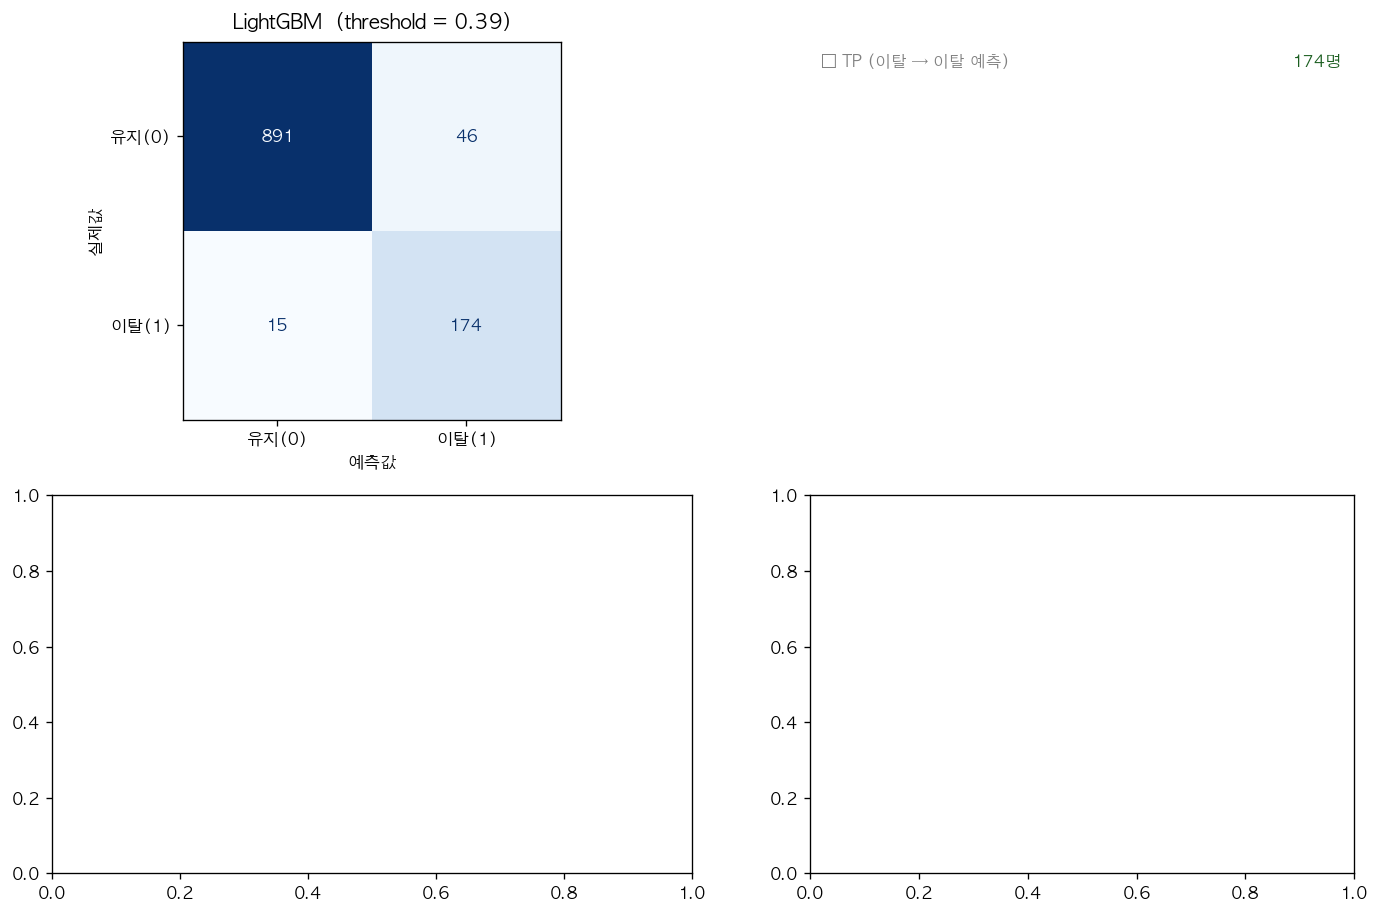

In [21]:
from sklearn.metrics import classification_report
import matplotlib.patches as mpatches

def plot_detailed_cm(model, X, y, name, threshold, ax_main, ax_meta):
    """혼동행렬 + TP/FP/FN/TN 비즈니스 해석 패널"""
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    cm   = confusion_matrix(y, pred)

    tn, fp, fn, tp = cm.ravel()
    total = len(y)
    churn_total = y.sum()

    # ── 왼쪽: 혼동행렬 히트맵 ─────────────────────────────────────────
    disp = ConfusionMatrixDisplay(cm, display_labels=["유지(0)","이탈(1)"])
    disp.plot(ax=ax_main, colorbar=False, cmap="Blues", values_format="d")
    ax_main.set_title(f"{name}  (threshold = {threshold})",
                      fontsize=12, fontweight="bold", pad=8)
    ax_main.set_xlabel("예측값", fontsize=10)
    ax_main.set_ylabel("실제값", fontsize=10)

    # ── 오른쪽: 지표 해설 패널 ────────────────────────────────────────
    ax_meta.axis("off")
    recall_val    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    fpr_val       = fp / (fp + tn) if (fp + tn) > 0 else 0

    lines = [
        ("✅ TP (이탈 → 이탈 예측)", f"{tp:,}명",    "#1B5E20"),
        ("❌ FN (이탈 → 유지 예측)", f"{fn:,}명",    "#B71C1C"),
        ("⚠️  FP (유지 → 이탈 예측)", f"{fp:,}명",   "#E65100"),
        ("✔️  TN (유지 → 유지 예측)", f"{tn:,}명",   "#1565C0"),
        ("", "", "black"),
        ("Recall  (이탈 탐지율)",  f"{recall_val*100:.1f}%",    "#1B5E20"),
        ("Precision (탐지 정확도)", f"{precision_val*100:.1f}%", "#1565C0"),
        ("FPR  (오탐율)",          f"{fpr_val*100:.1f}%",        "#B71C1C"),
        ("", "", "black"),
        ("이탈 고객 중 탐지 성공",   f"{tp}/{churn_total}명",     "#1B5E20"),
        ("이탈 고객 중 탐지 실패",   f"{fn}/{churn_total}명",     "#B71C1C"),
    ]
    y_pos = 0.97
    for label, value, color in lines:
        if label == "":
            y_pos -= 0.04; continue
        ax_meta.text(0.02, y_pos, label, transform=ax_meta.transAxes,
                     fontsize=9.5, va="top", color="gray")
        ax_meta.text(0.98, y_pos, value, transform=ax_meta.transAxes,
                     fontsize=10, va="top", ha="right", fontweight="bold", color=color)
        ax_meta.axhline(y_pos - 0.005, color="#e0e0e0", lw=0.5,
                        transform=ax_meta.transAxes)
        y_pos -= 0.088


# ── 2×2 subplot: 각 모델 × (CM | 해설)
fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                          gridspec_kw={"width_ratios": [1, 0.85]})

plot_detailed_cm(lgb_model, X_test, y_test, "LightGBM", lgb_th, axes[0][0], axes[0][1])
plot_detailed_cm(xgb_model, X_test, y_test, "XGBoost",  xgb_th, axes[1][0], axes[1][1])

plt.suptitle("Fig 4 — 혼동행렬 상세 분석 (Test Set)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 11-2. 분류 리포트 (Classification Report)

In [ ]:
def styled_report(model, X, y, name, threshold):
    """classification_report를 DataFrame으로 정리해 출력"""
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)

    report = classification_report(
        y, pred,
        target_names=["유지(0)", "이탈(1)"],
        output_dict=True
    )

    df_report = pd.DataFrame(report).T
    df_report = df_report.drop(columns=["support"], errors="ignore")

    # support 별도 추출
    support = pd.DataFrame(report).T["support"].astype(int)

    df_report["support"] = support
    df_report = df_report.round(4)

    print(f"\n{'='*52}")
    print(f"  {name}  |  threshold = {threshold}")
    print(f"{'='*52}")

    display(
        df_report.style
        .format({"precision":"{:.4f}","recall":"{:.4f}",
                 "f1-score":"{:.4f}","support":"{:.0f}"})
        .highlight_max(subset=["precision","recall","f1-score"],
                       axis=0, color="#c8f0c8")
        .set_properties(**{"text-align":"center"})
        .set_caption(f"{name} — Classification Report (Test Set)")
    )
    return df_report

lgb_report = styled_report(lgb_model, X_test, y_test, "LightGBM", lgb_th)
xgb_report = styled_report(xgb_model, X_test, y_test, "XGBoost",  xgb_th)

### 11-3. Precision-Recall 곡선 (PR Curve)
> 클래스 불균형 데이터에서는 ROC 보다 PR 곡선이 실질적인 성능을 더 잘 반영합니다.

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: PR Curve ──────────────────────────────────────────────────
ax = axes[0]
colors_pr = {"LightGBM": "#2196F3", "XGBoost": "#FF5722"}

for model, name in [(lgb_model, "LightGBM"), (xgb_model, "XGBoost")]:
    prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, lw=2.5, color=colors_pr[name],
            label=f"{name}  AP={ap:.4f}")

# 랜덤 베이스라인
baseline = y_test.mean()
ax.axhline(baseline, color="gray", lw=1.2, ls="--",
           label=f"Random baseline  ({baseline:.3f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("PR Curve (Test Set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── 오른쪽: 임계값별 Precision·Recall·F1 변화 ───────────────────────
ax2 = axes[1]
thresholds = np.arange(0.1, 0.95, 0.01)

for model, name, color in [
    (lgb_model, "LightGBM", "#2196F3"),
    (xgb_model, "XGBoost",  "#FF5722"),
]:
    prob = model.predict_proba(X_test)[:, 1]
    precs, recs, f1s = [], [], []
    for th in thresholds:
        pred = (prob >= th).astype(int)
        precs.append(precision_score(y_test, pred, zero_division=0))
        recs.append(recall_score(y_test, pred, zero_division=0))
        f1s.append(f1_score(y_test, pred, zero_division=0))

    ax2.plot(thresholds, recs,  lw=2,   color=color, ls="-",  label=f"{name} Recall")
    ax2.plot(thresholds, precs, lw=1.5, color=color, ls="--", label=f"{name} Precision", alpha=0.75)
    ax2.plot(thresholds, f1s,   lw=1.5, color=color, ls=":",  label=f"{name} F1", alpha=0.6)

ax2.set_xlabel("Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("임계값별 Recall · Precision · F1 변화", fontsize=13, fontweight="bold")
ax2.legend(fontsize=8, ncol=2, loc="center left")
ax2.grid(alpha=0.3)
ax2.set_xlim(0.1, 0.9); ax2.set_ylim(0, 1.02)

plt.suptitle("Fig 5 — PR Curve & 임계값 민감도 분석 (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 11-4. 최종 평가 리포트

In [ ]:
# ════════════════════════════════════════════════════════════════════
# 최종 평가 리포트 — 수치 자동 계산 후 출력
# ════════════════════════════════════════════════════════════════════
from sklearn.metrics import average_precision_score

def get_metrics(model, X, y, threshold):
    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)
    cm   = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "acc" : accuracy_score(y, pred),
        "prec": precision_score(y, pred, zero_division=0),
        "rec" : recall_score(y, pred, zero_division=0),
        "f1"  : f1_score(y, pred, zero_division=0),
        "auc" : roc_auc_score(y, prob),
        "ap"  : average_precision_score(y, prob),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }

lgb_m = get_metrics(lgb_model, X_test, y_test, lgb_th)
xgb_m = get_metrics(xgb_model, X_test, y_test, xgb_th)

winner = "LightGBM" if lgb_m["rec"] >= xgb_m["rec"] else "XGBoost"
w = lgb_m if winner == "LightGBM" else xgb_m
w_th = lgb_th if winner == "LightGBM" else xgb_th

churn_total = int(y_test.sum())
caught      = int(w["tp"])
missed      = int(w["fn"])

report_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║              📋 고객 이탈 예측 모델 — 최종 평가 리포트              ║
╠══════════════════════════════════════════════════════════════════╣
║  평가 데이터 : Test Set  ({len(y_test):,}명 / 이탈 {churn_total}명)
╠══════════════════════════════════════════════════════════════════╣
║  [ 모델별 성능 비교 ]
║
║   지표          LightGBM (th={lgb_th})     XGBoost  (th={xgb_th})
║  ─────────────────────────────────────────────────────────────
║   Accuracy    {lgb_m['acc']:.4f}               {xgb_m['acc']:.4f}
║   Precision   {lgb_m['prec']:.4f}               {xgb_m['prec']:.4f}
║   Recall    ★ {lgb_m['rec']:.4f}               {xgb_m['rec']:.4f}
║   F1-Score    {lgb_m['f1']:.4f}               {xgb_m['f1']:.4f}
║   ROC-AUC     {lgb_m['auc']:.4f}               {xgb_m['auc']:.4f}
║   Avg Prec    {lgb_m['ap']:.4f}               {xgb_m['ap']:.4f}
║
╠══════════════════════════════════════════════════════════════════╣
║  [ 최종 추천 모델 : {winner} ]
║
║  ✅ 이탈 고객 탐지 성공  : {caught}명 / {churn_total}명 ({caught/churn_total*100:.1f}%)
║  ❌ 이탈 고객 탐지 실패  : {missed}명 / {churn_total}명 ({missed/churn_total*100:.1f}%)
║  ⚠️  정상→이탈 오탐     : {int(w['fp'])}명
║
║  [ 선택 근거 ]
║  • Recall {w['rec']*100:.1f}% — 이탈 고객을 놓치는 비용이 크기 때문에
║    재현율(Recall) 기준으로 최적 모델을 선택합니다.
║  • ROC-AUC {w['auc']:.4f} — 전반적 판별력도 우수합니다.
║  • 임계값 {w_th} — F1을 최대화하는 최적 임계값입니다.
║    (기본값 0.5 대비 Recall 추가 향상)
║
║  [ 비즈니스 인사이트 ]
║  • 핵심 이탈 신호: Tenure(이용기간)↓, Complain(불만접수)↑,
║                   DaySinceLastOrder(주문 공백)↑
║  • 위험 구간: 신규(0-3개월), 쿠폰 고빈도(6-9회), 근거리 배송 고객
║  • 그룹 관리: '라이프스테이지 반응성' 점수 높은 고객 우선 개입
╚══════════════════════════════════════════════════════════════════╝
"""
print(report_text)